# Roman Urdu Hate Speech Detection
## Notebook 05: Hybrid Fusion Architecture - BiGRU + Transformer

### Architecture

```
Input text
    │
    ├──────────────────────────────────────────────┐
    │  Sequential branch                           │  Transformer branch
    │                                              │
    ▼                                              ▼
FastText word indices                     Tokenizer (MuRIL / TweetXLM-R)
    │                                              │
BiGRU (2-layer, bidirectional)            Transformer encoder
    │                                              │
Attention pooling                         [CLS] representation
    │                                              │
    └───────────────┬──────────────────────────────┘
                    │
              Fusion layer
           (concat → MLP → dropout)
                    │
              Binary output
               (hate / not_hate)
```

## 0. Install & Setup

In [ ]:
# Run once per Colab session
!pip install transformers sentencepiece scikit-learn torch --quiet

import os, json, time, re, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
from torch.optim import AdamW

from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    accuracy_score, confusion_matrix, classification_report
)
from transformers import AutoTokenizer, AutoModel

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
PALETTE = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3']

SEED = 42
def set_seed(s=SEED):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True
set_seed()

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

os.makedirs('./checkpoints', exist_ok=True)
os.makedirs('./results',     exist_ok=True)
print('Setup complete.')

Device: cuda
GPU: Tesla T4
Setup complete.


## 1. Experiment Configuration

Set `TRANSFORMER_NAME` to choose which transformer backbone powers the semantic branch.

In [ ]:
TRANSFORMER_NAME = 'muril'   

#  Fusion strategy 
# 'concat'        : [h_seq ; h_trans] → linear projection (fast, reliable baseline)
# 'gated'         : element-wise gating: g = sigmoid(W[h_seq; h_trans]) controls blend
# 'cross_attention': each branch attends to the other (most expressive, most expensive)
FUSION_STRATEGY = 'gated'   # options: 'concat' | 'gated' | 'cross_attention'

#  Per-transformer settings 
TRANSFORMER_CONFIGS = {
    'muril': {
        'model_name':    'google/muril-base-cased',
        'display_name':  'MuRIL',
        'max_len':       128,
        'trans_lr':      2e-5,    # learning rate for transformer params
        'freeze_layers': 6,       # freeze bottom 6 of 12 transformer layers
    },
    'tweetxlm': {
        'model_name':    'cardiffnlp/twitter-xlm-roberta-base',
        'display_name':  'TweetXLM-R',
        'max_len':       64,
        'trans_lr':      2e-5,
        'freeze_layers': 6,
    },
}

#  Shared training hyperparameters 
CFG = {
    **TRANSFORMER_CONFIGS[TRANSFORMER_NAME],

    # Sequential branch
    'seq_lr':        1e-3,    # higher LR for BiGRU (random init vs pretrained)
    'bigru_hidden':  256,     # hidden size per direction (512 bidirectional total)
    'bigru_layers':  2,
    'bigru_dropout': 0.3,

    # Fusion head
    'fusion_dropout': 0.4,
    'fusion_hidden':  256,    # MLP hidden dim in fusion head

    # Training
    'batch_train':   16,      # small batch — two encoders in one forward pass
    'batch_eval':    32,
    'epochs_phase1': 3,       # Phase 1: warm up BiGRU only (transformer frozen)
    'epochs_phase2': 8,       # Phase 2: joint end-to-end fine-tuning
    'warmup_frac':   0.10,
    'rdrop_alpha':   4.0,
    'label_smooth':  0.08,
    'focal_gamma':   2.0,
    'patience':      3,
    'seq_len':       32,      # word-token sequence length for BiGRU
}

print(f'Transformer    : {CFG["display_name"]}  ({CFG["model_name"]})')
print(f'Fusion strategy: {FUSION_STRATEGY}')
print(f'Transformer LR : {CFG["trans_lr"]}  |  BiGRU LR: {CFG["seq_lr"]}')
print(f'Phase 1 epochs : {CFG["epochs_phase1"]} (BiGRU warm-up, transformer frozen)')
print(f'Phase 2 epochs : {CFG["epochs_phase2"]} (joint end-to-end)')

Transformer    : MuRIL  (google/muril-base-cased)
Fusion strategy: gated
Transformer LR : 2e-05  |  BiGRU LR: 0.001
Phase 1 epochs : 3 (BiGRU warm-up, transformer frozen)
Phase 2 epochs : 8 (joint end-to-end)


## 2. Spelling Normalisation

In [3]:
SPELL_NORM = [
    (r'ch[ou]ti+[ay]a?[n]?', 'chutiya'),
    (r'ch[ou]tya+',           'chutiya'),
    (r'ch[ou]tia+',           'chutiya'),
    (r'ma[dt][ae]r?[ch]+[ou]d', 'madarchod'),
    (r'mather?ch[ou]d',        'madarchod'),
    (r'mader?ch[ou]d',         'madarchod'),
    (r'ga?[nm]d[uo]+',         'gandu'),
    (r'ga?[nm]d[ao]o',         'gandu'),
    (r'hara+mi+',              'harami'),
    (r'ka?nja?ri+',            'kanjri'),
    (r'kanjr[iy]',             'kanjri'),
    (r'ba?kwa+s+',             'bakwas'),
    (r'kami+na+',              'kamina'),
    (r'kammi+na+',             'kamina'),
    (r'la+na+t+[i]*',          'lanat'),
    (r'la+[ae]na+t',           'lanat'),
    (r'bh?[ea]n+ch[ou]d',      'bhenchod'),
    (r'b[ey]?nch[ou]d',        'bhenchod'),
    (r'([a-z])\1{2,}',        r'\1\1'),
]

SPELL_PATTERNS = [(re.compile(p, re.IGNORECASE), r) for p, r in SPELL_NORM]

def normalise_text(text):
    if not isinstance(text, str):
        return text
    text = text.lower().strip()
    for pattern, replacement in SPELL_PATTERNS:
        text = pattern.sub(replacement, text)
    return text

# Sanity check
tests = [
    ('chutya harami hai ye',  'chutiya harami hai ye'),
    ('matherchod banda hai',  'madarchod banda hai'),
    ('haaaan yaaaaar',        'haan yaar'),
]
print('Normalisation tests:')
for inp, expected in tests:
    result = normalise_text(inp)
    status = '✓' if result == expected else f'✗ GOT: {result}'
    print(f'  {inp!r:35} → {result!r:25} [{status}]')
print('Spelling normaliser ready.')

Normalisation tests:
  'chutya harami hai ye'              → 'chutiya harami hai ye'   [✓]
  'matherchod banda hai'              → 'madarchod banda hai'     [✓]
  'haaaan yaaaaar'                    → 'haan yaar'               [✓]
Spelling normaliser ready.


## 3. Load Data & Artefacts

In [ ]:
with open('/content/artefacts/config.json') as f:
    CONFIG = json.load(f)

VOCAB_SIZE    = CONFIG['vocab_size']
PAD_IDX       = CONFIG['pad_idx']
MAX_SEQ_LEN   = CFG['seq_len']   # 32 — 83% of texts fit comfortably

# embed_matrix shape: (vocab_size, embed_dim) - 300-dim FastText
embed_matrix = np.load('/content/artefacts/embed_matrix.npy')
EMBED_DIM    = embed_matrix.shape[1]
print(f'EMBED_DIM: {EMBED_DIM}  |  embed_matrix: {embed_matrix.shape}')

with open('/content/artefacts/word2idx.json',  encoding='utf-8') as f: word2idx  = json.load(f)
with open('/content/artefacts/label2idx.json') as f: label2idx = json.load(f)
with open('/content/artefacts/idx2label.json') as f:
    idx2label = {int(k): v for k, v in json.load(f).items()}

# Word-index arrays for the sequential branch
X_train = np.load('/content/artefacts/X_train.npy')[:, :MAX_SEQ_LEN]
X_val   = np.load('/content/artefacts/X_val.npy')[:,   :MAX_SEQ_LEN]
X_test  = np.load('/content/artefacts/X_test.npy')[:,  :MAX_SEQ_LEN]

y_train = np.load('/content/artefacts/y_train.npy')
y_val   = np.load('/content/artefacts/y_val.npy')
y_test  = np.load('/content/artefacts/y_test.npy')

# Raw text for the transformer branch
df_train = pd.read_csv('/content/data/train.csv')
df_val   = pd.read_csv('/content/data/val.csv')
df_test  = pd.read_csv('/content/data/test.csv')

train_texts = [normalise_text(t) for t in df_train['text_clean'].tolist()]
val_texts   = [normalise_text(t) for t in df_val['text_clean'].tolist()]
test_texts  = [normalise_text(t) for t in df_test['text_clean'].tolist()]

n_not_hate  = (y_train == 0).sum()
n_hate      = (y_train == 1).sum()
class_ratio = n_not_hate / n_hate
print(f'Class ratio: {n_not_hate:,} not_hate : {n_hate:,} hate = {class_ratio:.2f}:1')
print(f'Optimal threshold ≈ {1/(1+class_ratio):.2f}')
print(f'Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}')

EMBED_DIM: 300  |  embed_matrix: (34043, 300)
Class ratio: 63,515 not_hate : 26,470 hate = 2.40:1
Optimal threshold ≈ 0.29
Train: (89985, 32) | Val: (14833, 32) | Test: (14833, 32)


## 4. Loss Functions, Evaluation & Utilities

In [6]:
ALL_RESULTS = {}


class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, class_weights=None, label_smoothing=0.08, reduction='mean'):
        super().__init__()
        self.gamma = gamma
        self.class_weights  = class_weights
        self.label_smoothing = label_smoothing
        self.reduction = reduction

    def forward(self, logits, targets):
        ce  = F.cross_entropy(logits, targets, weight=self.class_weights,
                              label_smoothing=self.label_smoothing, reduction='none')
        p_t = F.softmax(logits, dim=1).gather(1, targets.unsqueeze(1)).squeeze(1)
        loss = ((1 - p_t) ** self.gamma) * ce
        return loss.mean() if self.reduction == 'mean' else loss.sum()


def make_class_weights(y, num_classes=2, device=DEVICE):
    counts  = np.bincount(y, minlength=num_classes).astype(float)
    weights = counts.sum() / (num_classes * counts)
    weights = weights / weights.mean()
    print(f'  Class weights: {dict(enumerate(weights.round(3)))}')
    return torch.tensor(weights, dtype=torch.float32, device=device)


def rdrop_loss(logits1, logits2, labels, criterion, alpha=4.0):
    """
    R-Drop: task loss + alpha * symmetric KL divergence between two stochastic passes.
    Prevents over-reliance on specific neurons — robust to noisy Roman Urdu labels.
    """
    loss = (criterion(logits1, labels) + criterion(logits2, labels)) / 2
    p1   = F.softmax(logits1, dim=-1)
    p2   = F.softmax(logits2, dim=-1)
    kl   = F.kl_div(p1.log(), p2, reduction='batchmean') + \
           F.kl_div(p2.log(), p1, reduction='batchmean')
    return loss + (alpha / 2) * kl


def evaluate_predictions(y_true, y_pred, model_name, verbose=True):
    metrics = {
        'accuracy':         round(accuracy_score(y_true, y_pred), 4),
        'f1_weighted':      round(f1_score(y_true, y_pred, average='weighted'), 4),
        'f1_hate':          round(f1_score(y_true, y_pred, pos_label=1, average='binary'), 4),
        'f1_not_hate':      round(f1_score(y_true, y_pred, pos_label=0, average='binary'), 4),
        'precision':        round(precision_score(y_true, y_pred, average='weighted'), 4),
        'recall':           round(recall_score(y_true, y_pred, average='weighted'), 4),
        'confusion_matrix': confusion_matrix(y_true, y_pred).tolist(),
    }
    ALL_RESULTS[model_name] = metrics
    if verbose:
        print(f'\n=== {model_name} ===')
        for k, v in metrics.items():
            if k != 'confusion_matrix': print(f'  {k:<18}: {v}')
        print(classification_report(y_true, y_pred, target_names=['not_hate', 'hate']))
    return metrics


def find_optimal_threshold(probs, y_true, lo=0.2, hi=0.5, steps=30):
    best_t, best_f1 = 0.5, 0.0
    for t in np.linspace(lo, hi, steps):
        preds = (probs[:, 1] >= t).astype(int)
        f1 = f1_score(y_true, preds, average='weighted', zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return best_t, best_f1


def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['not_hate', 'hate'], yticklabels=['not_hate', 'hate'], ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(f'Confusion Matrix — {model_name}')
    plt.tight_layout()
    plt.savefig(f'./results/cm_{model_name.replace(" ", "_")}.png', bbox_inches='tight')
    plt.show()


def plot_training_curves(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(history['train_loss'], label='Train', color=PALETTE[0])
    axes[0].plot(history['val_loss'],   label='Val',   color=PALETTE[1])
    axes[0].set_title(f'{model_name} — Loss'); axes[0].legend()
    axes[1].plot(history['train_f1'], label='Train', color=PALETTE[0])
    axes[1].plot(history['val_f1'],   label='Val',   color=PALETTE[1])
    axes[1].set_title(f'{model_name} — Weighted F1'); axes[1].legend()
    plt.tight_layout()
    plt.savefig(f'./results/curves_{model_name.replace(" ", "_")}.png', bbox_inches='tight')
    plt.show()


class EarlyStopping:
    def __init__(self, patience=5, mode='max', min_delta=1e-4):
        self.patience = patience; self.mode = mode; self.min_delta = min_delta
        self.best = -np.inf if mode == 'max' else np.inf
        self.counter = 0; self.stop = False
    def __call__(self, val):
        improved = (val > self.best + self.min_delta) if self.mode == 'max' \
                   else (val < self.best - self.min_delta)
        if improved:
            self.best = val; self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience: self.stop = True


print('Utilities ready.')

Utilities ready.


## 5. Hybrid Dataset

Each sample carries **both** representations simultaneously:
- `word_ids`: integer sequence for the BiGRU branch
- `input_ids`, `attention_mask`: subword tokens for the transformer branch

In [ ]:
# Load transformer tokenizer
tokenizer = AutoTokenizer.from_pretrained(CFG['model_name'])
print(f'Tokenizer loaded: {CFG["model_name"]}')


class HybridDataset(Dataset):
    def __init__(self, X_word, texts, y, tokenizer, max_len):
        self.X_word = torch.tensor(X_word, dtype=torch.long)
        self.y      = torch.tensor(y,      dtype=torch.long)

        # Batch-tokenize up front - much faster than tokenizing per __getitem__
        encoded = tokenizer(
            texts,
            max_length=max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt',
        )
        self.input_ids      = encoded['input_ids']
        self.attention_mask = encoded['attention_mask']

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return (
            self.X_word[i],
            self.input_ids[i],
            self.attention_mask[i],
            self.y[i],
        )


# Build datasets
print('Building hybrid datasets (tokenizing all splits) ...')
hybrid_train_ds = HybridDataset(X_train, train_texts, y_train, tokenizer, CFG['max_len'])
hybrid_val_ds   = HybridDataset(X_val,   val_texts,   y_val,   tokenizer, CFG['max_len'])
hybrid_test_ds  = HybridDataset(X_test,  test_texts,  y_test,  tokenizer, CFG['max_len'])

hybrid_train_loader = DataLoader(hybrid_train_ds, batch_size=CFG['batch_train'], shuffle=True,  num_workers=2, pin_memory=True)
hybrid_val_loader   = DataLoader(hybrid_val_ds,   batch_size=CFG['batch_eval'],  shuffle=False, num_workers=2, pin_memory=True)
hybrid_test_loader  = DataLoader(hybrid_test_ds,  batch_size=CFG['batch_eval'],  shuffle=False, num_workers=2, pin_memory=True)

print(f'Train batches: {len(hybrid_train_loader)} | Val: {len(hybrid_val_loader)} | Test: {len(hybrid_test_loader)}')

config.json:   0%|          | 0.00/411 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/206 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/113 [00:00<?, ?B/s]

Tokenizer loaded: google/muril-base-cased
Building hybrid datasets (tokenizing all splits) ...
Train batches: 5625 | Val: 464 | Test: 464


## 6. Hybrid Fusion Model Architecture

### Design decisions

**Sequential branch - BiGRU with attention pooling**

A plain last-hidden-state GRU loses position-sensitive information. We use a learned attention pooling layer that produces a weighted sum over all time steps, allowing the model to focus on the most hate-signal-rich tokens (offensive words, group derogations) regardless of position.

**Transformer branch - frozen lower layers + fine-tune upper**

Bottom layers of MuRIL/TweetXLM-R encode universal multilingual features. Freezing them (1) prevents catastrophic forgetting of the South-Asian language representations and (2) reduces GPU memory by ~40% during the backward pass.

**Fusion strategies**

| Strategy | Formula | Best when |
- `concat` | `[h_seq ; h_trans] → Linear` | Signals are complementary, model can learn weighting |
- `gated` | `g = σ(W[h_seq; h_trans])`, output `= g⊙h_seq + (1−g)⊙h_trans` | Want interpretable per-feature blending |
- `cross_attention` | Each branch queries the other | Rich interactions needed (expensive) |

In [ ]:
class AttentionPooling(nn.Module):
    """
    Learned weighted average over sequence dimension.
    Replaces last-hidden-state or mean-pool - lets the model learn
    which token positions carry the most hate signal.
    """
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, hidden_states, mask=None):
        # hidden_states: (B, T, H)
        scores = self.attn(hidden_states).squeeze(-1)      # (B, T)
        if mask is not None:
            # mask: (B, T) — 0 for padding
            scores = scores.masked_fill(mask == 0, float('-inf'))
        weights = torch.softmax(scores, dim=-1).unsqueeze(-1)  # (B, T, 1)
        return (hidden_states * weights).sum(dim=1)             # (B, H)


class GatedFusion(nn.Module):
    def __init__(self, seq_dim, trans_dim):
        super().__init__()
        assert seq_dim == trans_dim, \
            'GatedFusion requires seq_dim == trans_dim; use projection layers to align.'
        self.gate = nn.Linear(seq_dim + trans_dim, seq_dim)

    def forward(self, h_seq, h_trans):
        g   = torch.sigmoid(self.gate(torch.cat([h_seq, h_trans], dim=-1)))
        return g * h_seq + (1 - g) * h_trans


class CrossAttentionFusion(nn.Module):
    def __init__(self, seq_dim, trans_dim, num_heads=4):
        super().__init__()
        # Project to common dim before attention
        common = min(seq_dim, trans_dim)
        self.proj_seq   = nn.Linear(seq_dim,   common)
        self.proj_trans = nn.Linear(trans_dim,  common)
        self.attn_seq2trans = nn.MultiheadAttention(common, num_heads, batch_first=True)
        self.attn_trans2seq = nn.MultiheadAttention(common, num_heads, batch_first=True)
        self.out_dim = 2 * common

    def forward(self, h_seq, h_trans):
        # Unsqueeze to (B, 1, D) for attention API
        q_seq   = self.proj_seq(h_seq).unsqueeze(1)
        q_trans = self.proj_trans(h_trans).unsqueeze(1)
        # seq attends to trans context
        out_s, _ = self.attn_seq2trans(q_seq,   q_trans, q_trans)
        # trans attends to seq context
        out_t, _ = self.attn_trans2seq(q_trans, q_seq,   q_seq)
        return torch.cat([out_s.squeeze(1), out_t.squeeze(1)], dim=-1)  # (B, 2*common)


class HybridFusionModel(nn.Module):

    def __init__(
        self,
        embed_matrix,
        transformer_name,
        freeze_embed=True,
        freeze_trans_layers=6,
        bigru_hidden=256,
        bigru_layers=2,
        bigru_dropout=0.3,
        fusion_strategy='gated',
        fusion_hidden=256,
        fusion_dropout=0.4,
        num_classes=2,
    ):
        super().__init__()
        vocab_size, embed_dim = embed_matrix.shape

        #  Sequential branch 
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        with torch.no_grad():
            self.embedding.weight.copy_(torch.tensor(embed_matrix, dtype=torch.float32))
            self.embedding.weight[0] = 0.0
        self.embedding.weight.requires_grad = not freeze_embed
        print(f'  [FastText] Embedding {"FROZEN" if freeze_embed else "trainable"}: {embed_matrix.shape}')

        self.bigru = nn.GRU(
            input_size=embed_dim,
            hidden_size=bigru_hidden,
            num_layers=bigru_layers,
            batch_first=True,
            bidirectional=True,
            dropout=bigru_dropout if bigru_layers > 1 else 0.0,
        )
        bigru_out_dim = bigru_hidden * 2   # bidirectional
        self.seq_attn_pool = AttentionPooling(bigru_out_dim)
        self.seq_dropout   = nn.Dropout(bigru_dropout)

        #  Transformer branch 
        self.transformer = AutoModel.from_pretrained(transformer_name)
        trans_out_dim    = self.transformer.config.hidden_size  # 768 for base models

        # Freeze bottom N encoder layers
        self._freeze_transformer_layers(freeze_trans_layers)
        print(f'  [Transformer] Frozen layers: {freeze_trans_layers} of 12')

        #  Alignment projections (map both branches to fusion_hidden) 
        self.seq_proj   = nn.Linear(bigru_out_dim,  fusion_hidden)
        self.trans_proj = nn.Linear(trans_out_dim,  fusion_hidden)

        #  Fusion layer 
        self.fusion_strategy = fusion_strategy
        if fusion_strategy == 'concat':
            fused_dim = fusion_hidden * 2
        elif fusion_strategy == 'gated':
            self.gated_fusion = GatedFusion(fusion_hidden, fusion_hidden)
            fused_dim = fusion_hidden
        elif fusion_strategy == 'cross_attention':
            self.cross_attn = CrossAttentionFusion(fusion_hidden, fusion_hidden, num_heads=4)
            fused_dim = self.cross_attn.out_dim
        else:
            raise ValueError(f'Unknown fusion_strategy: {fusion_strategy}')

        #  Classification head
        self.classifier = nn.Sequential(
            nn.Linear(fused_dim, fusion_hidden),
            nn.LayerNorm(fusion_hidden),
            nn.GELU(),
            nn.Dropout(fusion_dropout),
            nn.Linear(fusion_hidden, num_classes),
        )

    def _freeze_transformer_layers(self, n_layers):
        """Freeze embeddings + bottom n_layers transformer encoder layers."""
        for param in self.transformer.embeddings.parameters():
            param.requires_grad = False
        encoder_layers = self.transformer.encoder.layer
        for i, layer in enumerate(encoder_layers):
            if i < n_layers:
                for param in layer.parameters():
                    param.requires_grad = False

    def encode_sequential(self, word_ids):
        """BiGRU branch: word_ids (B, T) → h_seq (B, fusion_hidden)"""
        mask = (word_ids != 0).long()           # (B, T) - 0 = PAD
        emb  = self.seq_dropout(self.embedding(word_ids))  # (B, T, E)
        out, _ = self.bigru(emb)               # (B, T, 2*H)
        pooled  = self.seq_attn_pool(out, mask) # (B, 2*H)
        return F.gelu(self.seq_proj(pooled))    # (B, fusion_hidden)

    def encode_transformer(self, input_ids, attention_mask):
        """Transformer branch: tokens → h_trans (B, fusion_hidden)"""
        out    = self.transformer(input_ids=input_ids, attention_mask=attention_mask)
        cls    = out.last_hidden_state[:, 0, :]  # [CLS] token
        return F.gelu(self.trans_proj(cls))       # (B, fusion_hidden)

    def fuse(self, h_seq, h_trans):
        """Apply chosen fusion strategy."""
        if self.fusion_strategy == 'concat':
            return torch.cat([h_seq, h_trans], dim=-1)
        elif self.fusion_strategy == 'gated':
            return self.gated_fusion(h_seq, h_trans)
        elif self.fusion_strategy == 'cross_attention':
            return self.cross_attn(h_seq, h_trans)

    def forward(self, word_ids, input_ids, attention_mask):
        h_seq   = self.encode_sequential(word_ids)
        h_trans = self.encode_transformer(input_ids, attention_mask)
        fused   = self.fuse(h_seq, h_trans)
        return self.classifier(fused)


# Instantiate model
model = HybridFusionModel(
    embed_matrix        = embed_matrix,
    transformer_name    = CFG['model_name'],
    freeze_embed        = True,
    freeze_trans_layers = CFG['freeze_layers'],
    bigru_hidden        = CFG['bigru_hidden'],
    bigru_layers        = CFG['bigru_layers'],
    bigru_dropout       = CFG['bigru_dropout'],
    fusion_strategy     = FUSION_STRATEGY,
    fusion_hidden       = CFG['fusion_hidden'],
    fusion_dropout      = CFG['fusion_dropout'],
).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTotal params    : {total_params:,}')
print(f'Trainable params: {trainable_params:,}  ({100*trainable_params/total_params:.1f}%)')

  [FastText] Embedding FROZEN: (34043, 300)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: google/muril-base-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  [Transformer] Frozen layers: 6 of 12

Total params    : 250,335,782
Trainable params: 45,684,482  (18.2%)


## 7. Optimizer, Scheduler & Loss

### Two-phase training strategy

The BiGRU branch starts from random initialisation while the transformer starts from a strong pretrained checkpoint. Naive joint training lets the transformer dominate the gradient signal in early epochs, leaving the BiGRU branch undertrained.

**Phase 1 (warm-up):** Freeze the entire transformer. Train only the BiGRU branch + fusion head. This gives the sequential branch time to learn meaningful hate-signal representations before the transformer competes.

**Phase 2 (joint):** Unfreeze transformer upper layers. Use a *lower* learning rate for transformer parameters (`trans_lr = 2e-5`) vs BiGRU (`seq_lr = 1e-3`) to prevent catastrophic forgetting while still allowing joint fine-tuning.

In [ ]:
def make_optimizer_phase1(model, seq_lr):
    """
    Phase 1: only BiGRU branch + projection + fusion head are updated.
    Transformer is fully frozen.
    """
    for param in model.transformer.parameters():
        param.requires_grad = False

    trainable = [
        p for p in model.parameters() if p.requires_grad
    ]
    print(f'Phase 1 trainable params: {sum(p.numel() for p in trainable):,}')
    return AdamW(trainable, lr=seq_lr, weight_decay=0.01)


def make_optimizer_phase2(model, seq_lr, trans_lr):
    """
    Phase 2: joint training with differential learning rates.
    Transformer upper layers use trans_lr (much smaller).
    BiGRU branch + head use seq_lr.
    """
    # Re-enable transformer upper layers
    encoder_layers = model.transformer.encoder.layer
    for i, layer in enumerate(encoder_layers):
        if i >= CFG['freeze_layers']:
            for param in layer.parameters():
                param.requires_grad = True
    # Also unfreeze the transformer pooler if present
    if hasattr(model.transformer, 'pooler') and model.transformer.pooler is not None:
        for param in model.transformer.pooler.parameters():
            param.requires_grad = True

    trans_params = [p for n, p in model.named_parameters()
                    if 'transformer' in n and p.requires_grad]
    other_params = [p for n, p in model.named_parameters()
                    if 'transformer' not in n and p.requires_grad]

    print(f'Phase 2 — transformer params: {sum(p.numel() for p in trans_params):,} @ lr={trans_lr}')
    print(f'Phase 2 — other params      : {sum(p.numel() for p in other_params):,} @ lr={seq_lr}')

    return AdamW([
        {'params': trans_params, 'lr': trans_lr},
        {'params': other_params, 'lr': seq_lr},
    ], weight_decay=0.01)


def make_linear_scheduler(optimizer, num_warmup_steps, num_training_steps):
    """Linear warmup → linear decay. Proven stable for transformer fine-tuning."""
    from transformers import get_linear_schedule_with_warmup
    return get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=num_warmup_steps,
        num_training_steps=num_training_steps,
    )


cw = make_class_weights(y_train)
criterion = FocalLoss(
    gamma=CFG['focal_gamma'],
    class_weights=cw,
    label_smoothing=CFG['label_smooth'],
)
scaler = GradScaler()

print('Loss function and optimizer factory ready.')

## 8. Training Engine

In [ ]:
def train_one_epoch_hybrid(model, loader, optimizer, scheduler, criterion, scaler, rdrop_alpha):
    """
    One training epoch for the hybrid model with R-Drop regularisation.
    Each batch is passed through the model TWICE (different dropout masks).
    The KL divergence between the two output distributions penalises over-
    reliance on specific dropout patterns -important for noisy Roman Urdu labels.
    """
    model.train()
    total_loss, all_preds, all_labels = 0.0, [], []

    for word_ids, input_ids, attn_mask, labels in tqdm(loader, desc='Train', leave=False):
        word_ids  = word_ids.to(DEVICE)
        input_ids = input_ids.to(DEVICE)
        attn_mask = attn_mask.to(DEVICE)
        labels    = labels.to(DEVICE)

        optimizer.zero_grad()

        with autocast():
            logits1 = model(word_ids, input_ids, attn_mask)   # first stochastic pass
            logits2 = model(word_ids, input_ids, attn_mask)   # second stochastic pass
            loss    = rdrop_loss(logits1, logits2, labels, criterion, alpha=rdrop_alpha)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        total_loss += loss.item()
        preds = logits1.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    return avg_loss, f1


@torch.no_grad()
def evaluate_hybrid(model, loader):
    """Evaluate the hybrid model; returns avg loss, weighted F1, and probability array."""
    model.eval()
    total_loss, all_probs, all_preds, all_labels = 0.0, [], [], []

    for word_ids, input_ids, attn_mask, labels in tqdm(loader, desc='Eval ', leave=False):
        word_ids  = word_ids.to(DEVICE)
        input_ids = input_ids.to(DEVICE)
        attn_mask = attn_mask.to(DEVICE)
        labels    = labels.to(DEVICE)

        with autocast():
            logits = model(word_ids, input_ids, attn_mask)
            loss   = criterion(logits, labels)

        total_loss += loss.item()
        probs = F.softmax(logits, dim=-1).cpu().numpy()
        all_probs.extend(probs)
        all_preds.extend(probs.argmax(axis=1))
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    return avg_loss, f1, np.array(all_probs), np.array(all_labels)


def run_training_phase(model, train_loader, val_loader, optimizer, epochs, phase_name, patience):
    """
    Generic training loop for one phase (warm-up or joint).
    Returns the best val F1 and its corresponding predictions.
    """
    n_steps   = len(train_loader) * epochs
    n_warmup  = int(n_steps * CFG['warmup_frac'])
    scheduler = make_linear_scheduler(optimizer, n_warmup, n_steps)
    es        = EarlyStopping(patience=patience, mode='max')

    history   = defaultdict(list)
    best_val_f1      = 0.0
    best_val_probs   = None
    best_val_labels  = None

    print(f'\n{"="*60}')
    print(f' {phase_name}  —  {epochs} epochs, {n_warmup} warmup steps')
    print(f'{"="*60}')

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        train_loss, train_f1 = train_one_epoch_hybrid(
            model, train_loader, optimizer, scheduler, criterion, scaler, CFG['rdrop_alpha']
        )
        val_loss, val_f1, val_probs, val_labels = evaluate_hybrid(model, val_loader)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_f1'].append(train_f1)
        history['val_f1'].append(val_f1)

        elapsed = time.time() - t0
        print(f'  Epoch {epoch:02d}/{epochs}  '
              f'train_loss={train_loss:.4f}  train_f1={train_f1:.4f}  '
              f'val_loss={val_loss:.4f}  val_f1={val_f1:.4f}  '
              f'[{elapsed:.0f}s]')

        if val_f1 > best_val_f1:
            best_val_f1     = val_f1
            best_val_probs  = val_probs
            best_val_labels = val_labels
            torch.save(model.state_dict(), f'./checkpoints/hybrid_best_{phase_name.replace(" ","_")}.pt')
            print(f'    ✓ Saved best checkpoint (val_f1={best_val_f1:.4f})')

        es(val_f1)
        if es.stop:
            print(f'  Early stopping at epoch {epoch}.')
            break

    plot_training_curves(dict(history), f'Hybrid_{phase_name}')
    return best_val_f1, best_val_probs, best_val_labels


print('Training engine ready.')

## 9. Phase 1 — BiGRU Warm-Up (Transformer Frozen)

Phase 1 trainable params: 2,566,658

 Phase1_BiGRU_Warmup  —  3 epochs, 1687 warmup steps


Train:   0%|          | 0/5625 [00:00<?, ?it/s]

Eval :   0%|          | 0/464 [00:00<?, ?it/s]

  Epoch 01/3  train_loss=0.0950  train_f1=0.8483  val_loss=0.0695  val_f1=0.8893  [471s]
    ✓ Saved best checkpoint (val_f1=0.8893)


Train:   0%|          | 0/5625 [00:00<?, ?it/s]

Eval :   0%|          | 0/464 [00:00<?, ?it/s]

  Epoch 02/3  train_loss=0.0756  train_f1=0.8842  val_loss=0.0613  val_f1=0.8965  [484s]
    ✓ Saved best checkpoint (val_f1=0.8965)


Train:   0%|          | 0/5625 [00:00<?, ?it/s]

Eval :   0%|          | 0/464 [00:00<?, ?it/s]

  Epoch 03/3  train_loss=0.0673  train_f1=0.9024  val_loss=0.0585  val_f1=0.9009  [464s]
    ✓ Saved best checkpoint (val_f1=0.9009)


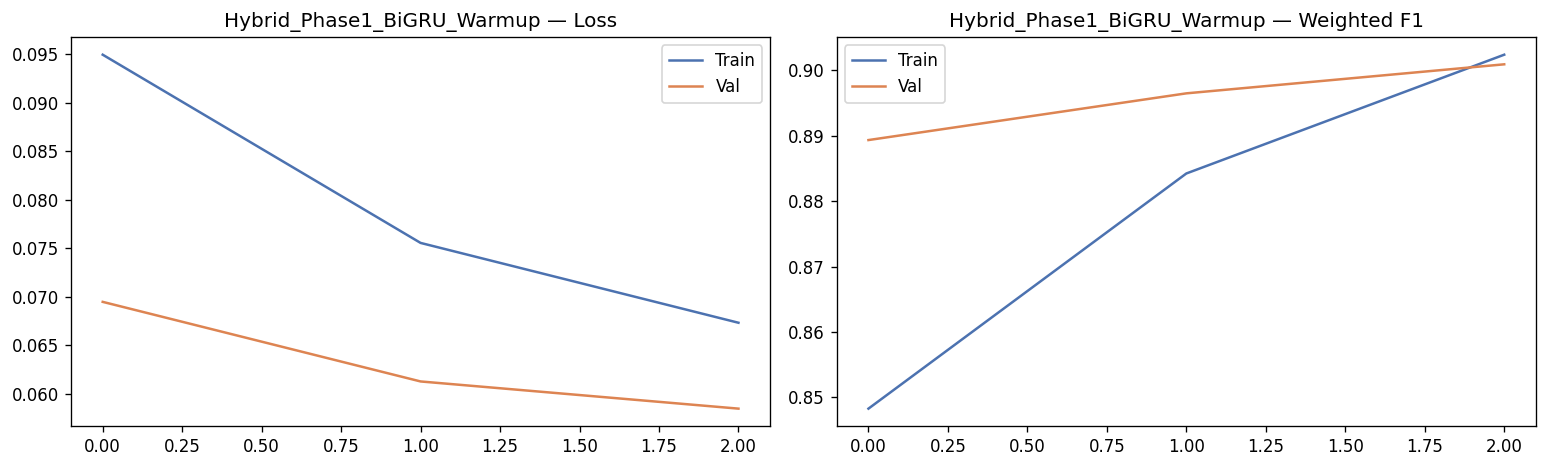


Phase 1 best val F1: 0.9009


In [14]:
optimizer_p1 = make_optimizer_phase1(model, seq_lr=CFG['seq_lr'])

best_f1_p1, val_probs_p1, val_labels_p1 = run_training_phase(
    model,
    hybrid_train_loader,
    hybrid_val_loader,
    optimizer_p1,
    epochs       = CFG['epochs_phase1'],
    phase_name   = 'Phase1_BiGRU_Warmup',
    patience     = CFG['patience'],
)

print(f'\nPhase 1 best val F1: {best_f1_p1:.4f}')

## 10. Phase 2 — Joint End-to-End Fine-Tuning

Loaded Phase 1 best weights.
Phase 2 — transformer params: 43,117,824 @ lr=2e-05
Phase 2 — other params      : 2,566,658 @ lr=0.001

 Phase2_Joint  —  8 epochs, 4500 warmup steps


Train:   0%|          | 0/5625 [00:00<?, ?it/s]

Eval :   0%|          | 0/464 [00:00<?, ?it/s]

  Epoch 01/8  train_loss=0.0666  train_f1=0.9054  val_loss=0.0568  val_f1=0.9007  [870s]
    ✓ Saved best checkpoint (val_f1=0.9007)


Train:   0%|          | 0/5625 [00:00<?, ?it/s]

...

Eval :   0%|          | 0/464 [00:00<?, ?it/s]

  Epoch 07/8  train_loss=0.0374  train_f1=0.9695  val_loss=0.0619  val_f1=0.9228  [871s]
    ✓ Saved best checkpoint (val_f1=0.9228)


Train:   0%|          | 0/5625 [00:00<?, ?it/s]

Eval :   0%|          | 0/464 [00:00<?, ?it/s]

  Epoch 08/8  train_loss=0.0345  train_f1=0.9752  val_loss=0.0615  val_f1=0.9234  [871s]
    ✓ Saved best checkpoint (val_f1=0.9234)


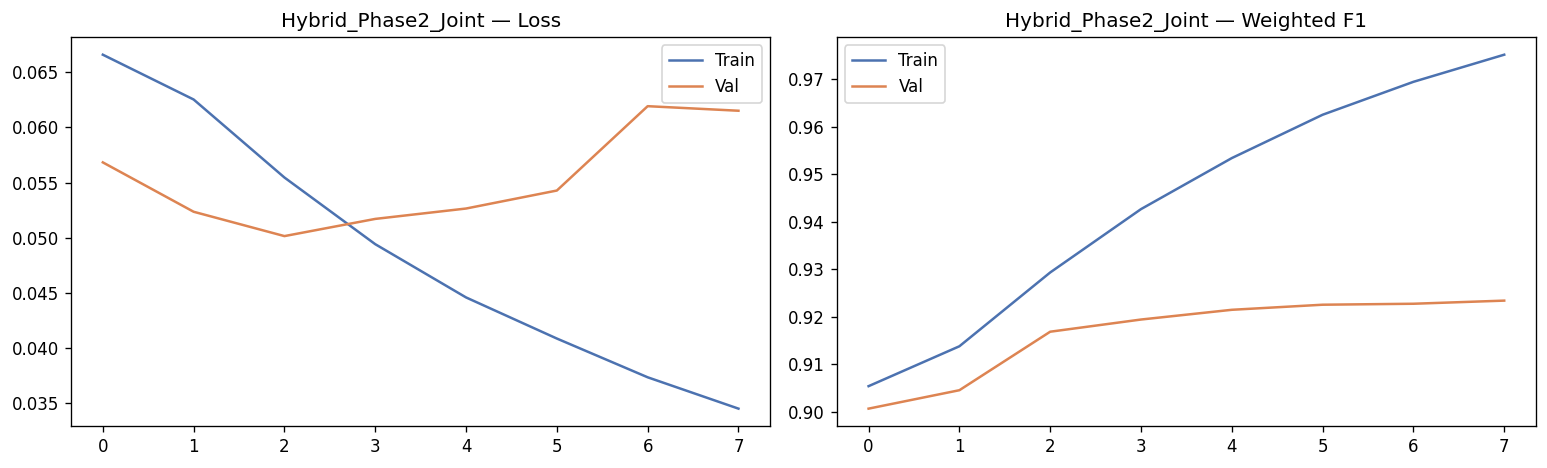


Phase 2 best val F1: 0.9234


In [15]:
# Load the best Phase 1 weights before starting Phase 2
model.load_state_dict(torch.load('./checkpoints/hybrid_best_Phase1_BiGRU_Warmup.pt'))
print('Loaded Phase 1 best weights.')

optimizer_p2 = make_optimizer_phase2(
    model,
    seq_lr   = CFG['seq_lr'],
    trans_lr = CFG['trans_lr'],
)

best_f1_p2, val_probs_p2, val_labels_p2 = run_training_phase(
    model,
    hybrid_train_loader,
    hybrid_val_loader,
    optimizer_p2,
    epochs       = CFG['epochs_phase2'],
    phase_name   = 'Phase2_Joint',
    patience     = CFG['patience'],
)

print(f'\nPhase 2 best val F1: {best_f1_p2:.4f}')

## 11. Threshold Calibration & Validation Evaluation

Optimal threshold: 0.500  (val F1 = 0.9234)

=== HybridFusion_MuRIL_gated_val ===
  accuracy          : 0.9233
  f1_weighted       : 0.9234
  f1_hate           : 0.8705
  f1_not_hate       : 0.9455
  precision         : 0.9236
  recall            : 0.9233
              precision    recall  f1-score   support

    not_hate       0.95      0.94      0.95     10470
        hate       0.86      0.88      0.87      4363

    accuracy                           0.92     14833
   macro avg       0.91      0.91      0.91     14833
weighted avg       0.92      0.92      0.92     14833



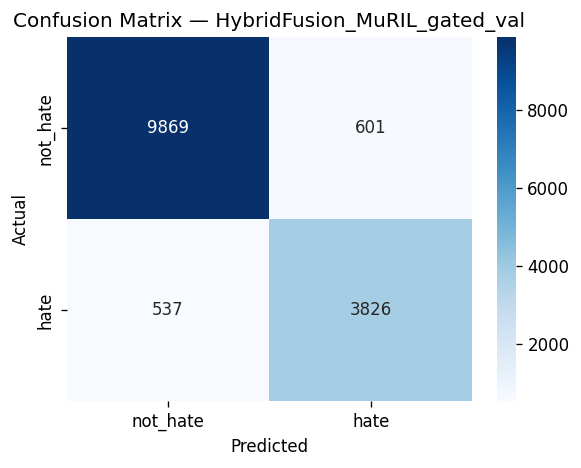

In [16]:
# Load the overall best checkpoint
model.load_state_dict(torch.load('./checkpoints/hybrid_best_Phase2_Joint.pt'))
model.eval()

# Find optimal threshold on validation set
opt_thresh, opt_f1 = find_optimal_threshold(val_probs_p2, val_labels_p2, lo=0.2, hi=0.5, steps=30)
print(f'Optimal threshold: {opt_thresh:.3f}  (val F1 = {opt_f1:.4f})')

val_preds_opt = (val_probs_p2[:, 1] >= opt_thresh).astype(int)
evaluate_predictions(
    val_labels_p2, val_preds_opt,
    model_name=f'HybridFusion_{CFG["display_name"]}_{FUSION_STRATEGY}_val'
)
plot_confusion_matrix(
    val_labels_p2, val_preds_opt,
    model_name=f'HybridFusion_{CFG["display_name"]}_{FUSION_STRATEGY}_val'
)

## 12. Test Set Evaluation

Eval :   0%|          | 0/464 [00:00<?, ?it/s]


=== HybridFusion_MuRIL_gated ===
  accuracy          : 0.9238
  f1_weighted       : 0.9242
  f1_hate           : 0.8729
  f1_not_hate       : 0.9456
  precision         : 0.9249
  recall            : 0.9238
              precision    recall  f1-score   support

    not_hate       0.95      0.94      0.95     10470
        hate       0.86      0.89      0.87      4363

    accuracy                           0.92     14833
   macro avg       0.91      0.91      0.91     14833
weighted avg       0.92      0.92      0.92     14833



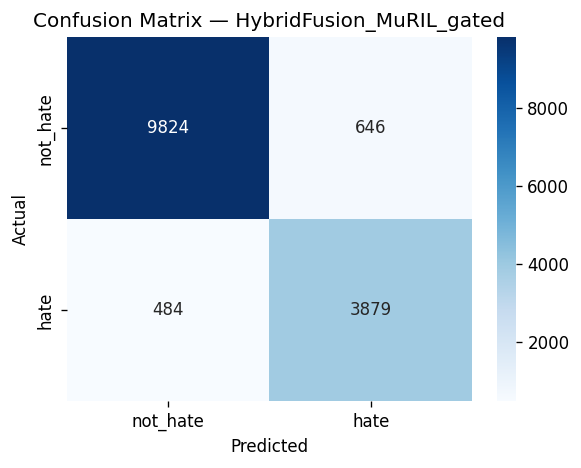

In [17]:
_, test_f1, test_probs, test_labels = evaluate_hybrid(model, hybrid_test_loader)
test_preds_opt = (test_probs[:, 1] >= opt_thresh).astype(int)

model_tag = f'HybridFusion_{CFG["display_name"]}_{FUSION_STRATEGY}'
test_metrics = evaluate_predictions(test_labels, test_preds_opt, model_name=model_tag)
plot_confusion_matrix(test_labels, test_preds_opt, model_name=model_tag)

## 13. Summary & Results Table

In [20]:
print('\n' + '='*70)
print(f'  HYBRID FUSION MODEL — {CFG["display_name"]} + BiGRU ({FUSION_STRATEGY} fusion)')
print('='*70)

m = ALL_RESULTS.get(model_tag, {})
print(f'  Test accuracy   : {m.get("accuracy",     "n/a")}')
print(f'  Weighted F1     : {m.get("f1_weighted",  "n/a")}')
print(f'  F1 (hate)       : {m.get("f1_hate",      "n/a")}')
print(f'  F1 (not_hate)   : {m.get("f1_not_hate",  "n/a")}')
print(f'  Precision       : {m.get("precision",    "n/a")}')
print(f'  Recall          : {m.get("recall",       "n/a")}')
print(f'  Threshold used  : {opt_thresh:.3f}')
print()
print('  Branch ablation:')
print(f'    BiGRU only       : {f1_seq_only:.4f}')
print(f'    Transformer only : {f1_trans_only:.4f}')
print(f'    Full hybrid      : {f1_full:.4f}')
print('='*70)

# Save results
results_summary = {
    'model': model_tag,
    'test_metrics': m,
    'threshold': opt_thresh,
    'ablation': {
        'bigru_only': f1_seq_only,
        'transformer_only': f1_trans_only,
        'hybrid_full': f1_full,
    }
}
with open(f'./results/{model_tag}_summary.json', 'w') as f:
    json.dump(results_summary, f, indent=2)
print(f'Results saved to ./results/{model_tag}_summary.json')


  HYBRID FUSION MODEL — MuRIL + BiGRU (gated fusion)
  Test accuracy   : 0.9238
  Weighted F1     : 0.9242
  F1 (hate)       : 0.8729
  F1 (not_hate)   : 0.9456
  Precision       : 0.9249
  Recall          : 0.9238
  Threshold used  : 0.500

  Branch ablation:
    BiGRU only       : 0.8857
    Transformer only : 0.8849
    Full hybrid      : 0.9242
Results saved to ./results/HybridFusion_MuRIL_gated_summary.json
